# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：032402125
- 姓名：潘逸诗
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-panyishi
- 数据文件：`ershoufang_list.csv`

##  摘要

本报告聚焦于福州市存量房市场的核心价格驱动要素与时空分布特征，通过全景探索性数据分析（EDA）解构其价值锚点与流动性机制。研究首先采用前置临时脱敏探测技术，成功识别并根治了因单位字符包裹带来的 26 条隐性缺失数据及文本空格污染等痛点，为后续挖掘构筑了高质量的基准分析矩阵。在此基础上，报告引入四分位距（IQR）法科学界定了高端房产右尾偏态异常值的数理边界，完成了改善型刚需房源的多条件复合筛选，并深度交叉构建了具有常规历史时间序列的“市区×房龄”二维均价中位数透视表。

在可视化呈现阶段，报告依托 `matplotlib` 与 `seaborn` 框架，高分辨率地规范渲染了全局单价核密度估计直方图、双轴供需错配对比图、多组分位数并列箱线图以及 Pearson 相关性热力图。这些图表不仅消除了单调性，更以严谨的数理标注直观展现了要素间的共振强度。每张图表均附带高度定量化的数理研判与经济解读，确保图形结论在后续的业务洞察中具备无懈可击的实证支撑力。

实证研究与相关性定量矩阵最终证实，福州市存量房市场表现出高度集中的地域极化与时空非均衡分化特征。晋安与仓山两区作为核心供给大盘垄断了市场最丰沛的刚需流动性，而鼓楼区则凭借不可复制的行政、医疗与顶级学区资源构筑了高额的价格溢价护城河，其挂牌单价中位数逼近 27,243 元/㎡。与此同时，房屋的物理建筑面积是框定房产总价值的定海神针，其与总价的强正相关系数高达 0.672；而由于设备老化与物业退化带来的时间折旧因子对单价具有显著的负向贴现贬值影响，这也倒逼当代次新房在空间尺度上正全面向 90–140㎡ 的高坪效标准化改善型户型集中收敛。

## 模块1：项目说明与分析目标

### 1.1 项目背景与宏观概述
在我国宏观经济迈入高质量发展阶段、房地产市场供求关系发生重大转变的当下，存量房（二手房）市场已成为透视城市居民真实居住需求、区域经济活力以及资产配置趋势的微观核心窗口。福州作为海峡西岸经济区的心脏，其存量房市场呈现出强烈的地缘性与多维驱动特征。

本报告基于福州市最新的一手二手房源挂牌数据集 `ershoufang_list.csv` 开展严谨的探索性数据分析（EDA）。该数据集包含 11,856 条详实的房源记录，横跨 18 个多维字段。

### 1.2 核心分析目标
本报告旨在通过规范、工程化的数据清洗流程与多维度的数理统计探索，解构福州存量房市场的内在价值锚点，主要研究目标包括：
1. **数据质量全面治理**：设计兼具抗噪性与科学性的清洗策略，针对隐性缺失值、格式污点、文本单位混杂进行工程化转换，建立高质量的基准分析矩阵。
2. **空间格局分化剖析**：测度福州不同行政区划（市区）在房源供应弹性、均价中位数及总价分布层面的空间分化。
3. **物理属性对财富价值的驱动机制**：量化户型、建筑面积等核心物理结构对房产总挂牌价格的边际贡献。
4. **时间与空间的交互作用探索**：通过二维交叉透视技术，解构“行政区 × 房龄”复合维度下的折旧效应与资产增值弹性，为市场走势研判和购房者理性决策提供客观、定量的数据支撑。


## 模块2：导入依赖库 + 读取CSV数据

### 2.1 环境配置与中文字体防乱码声明
为保障多维统计分析与高分辨率可视化的顺利执行，本模块将统一导入 Python 数据科学的核心依赖库。同时，针对 matplotlib/seaborn 在 Linux/Mac/Windows 跨平台运行时的中文字体缺失问题，代码中显式指定了系统级的中文字体族顺序，并关闭了负号渲染异常，确保图形资产的工业级呈现。

### 2.2 多重编码兼容读取机制
在生产环境的数据读取中，由于不同操作系统文件导出的差异，极易引发 `UnicodeDecodeError`。本模块设计了双重编码防御机制：优先采用带有 Byte Order Mark (BOM) 解析能力的 `utf-8-sig` 编码进行数据流读取，当捕获异常时自动降级切换至标准 `utf-8`。

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 统一配置高分辨率可视化图表样式与中文字体环境
plt.rcParams['figure.dpi'] = 120  # 提升图像呈现清晰度
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid", {"font.sans-serif": ['SimHei', 'Microsoft YaHei']})

# 2. 动态编码兼容保障读取数据
data_path = 'ershoufang_list.csv'
try:
    df = pd.read_csv(data_path, encoding='utf-8-sig')
    print("【系统状态】成功通过 'utf-8-sig' 编码挂载数据源。")
except Exception as e:
    print(f"【降级警告】utf-8-sig 读取失败，正在尝试切换至普通 utf-8。错误追踪: {e}")
    df = pd.read_csv(data_path, encoding='utf-8')

# 3. 基础规模断言
print(f"【元数据审计】当前原始数据集规模：{df.shape[0]} 行 × {df.shape[1]} 列")

【系统状态】成功通过 'utf-8-sig' 编码挂载数据源。
【元数据审计】当前原始数据集规模：11856 行 × 18 列


## 模块3：数据基础探查

本模块通过高层次的信息抽象（元数据审计）与低层次的切片探查，宏观把握数据集的字段拓扑结构。我们将明确各字段的数据类型，审查分类字段与连续型数值字段的分布大体情况，从而构建初始的业务映射。

In [14]:
print("=== 3.1 字段拓扑结构与非空计数审计 ===")
print(df.info())

print("\n=== 3.2 顶层样本切片观察（前3行） ===")
display(df.head(3))

print("\n=== 3.3 分类字段广度分布统计 ===")
print(f"数据覆盖的行政市区数量: {df['市区'].nunique()} 个\n具体包含的行政区划: {df['市区'].unique()}")
print(f"城市标签统一性检测: {df['城市'].unique()}")

=== 3.1 字段拓扑结构与非空计数审计 ===
<class 'pandas.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  str    
 2   市区      11856 non-null  str    
 3   标题      11856 non-null  str    
 4   户型      11856 non-null  str    
 5   面积      11856 non-null  str    
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  str    
 8   楼层      11856 non-null  str    
 9   时间      11856 non-null  str    
 10  所属小区    11856 non-null  str    
 11  所属区域    11856 non-null  str    
 12  房源链接    11856 non-null  str    
 13  总价      11830 non-null  str    
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  str    
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  str    
dtypes: float64(3), int64(1), str(14)
memory usage: 1.6 MB
None

=== 3.2 顶层样本切片观察（前3行） ===


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内



=== 3.3 分类字段广度分布统计 ===
数据覆盖的行政市区数量: 12 个
具体包含的行政区划: <StringArray>
['台江', '晋安', '鼓楼', '仓山', '闽侯', '连江', '福清', '平潭', '长乐', '马尾', '永泰', '罗源']
Length: 12, dtype: str
城市标签统一性检测: <StringArray>
['fuzhou']
Length: 1, dtype: str


## 模块4：数据质量全面检测（Data Quality Audit Report）

### 4.1 数据质量工程审计架构与隐性缺失探测
在构建任何高级数理统计结论前，必须对原始数据集执行严谨的质量审计。由于原始数据中 `总价`、`均价`、`面积` 被行业级度量单位（万、元/㎡、㎡）文本包裹，表现为 `object` 类型，普通的 `isnull()` 算子无法有效测度夹杂在其中的隐性缺失值。

因此，本模块采用**前置临时脱敏脱模探测技术**，利用 `pd.to_numeric(..., errors='coerce')` 算子将非法文本及隐性空值转换为标准 `NaN`。从**数据完整度（Completeness）**、**空间唯一性（Uniqueness）**、**文本格式一致性（Consistency）**四个维度进行深层全自动化扫描，解决前后期末报告数据对齐冲突的工程痛点。

In [15]:
print("==========================================================================================")
print("【数据质量审计看板 V2.0】系统正在对全域 11,856 条初始化样本执行多维健壮性扫描...")
print("==========================================================================================")

# 1. 健壮性前置处理：探测连续型变量中的隐性数值缺失，避免字符包裹欺骗 isnull()
total_price_numeric = pd.to_numeric(df['总价'].str.replace('万', '', regex=False), errors='coerce')
unit_price_numeric = pd.to_numeric(df['均价'].str.replace('元/㎡', '', regex=False), errors='coerce')
area_numeric = pd.to_numeric(df['面积'].str.replace('㎡', '', regex=False), errors='coerce')

# 构建精准的缺失矩阵
missing_count = df.isnull().sum()
# 将真正物理意义上的数值隐性缺失同步校准进来
missing_count['总价'] = total_price_numeric.isnull().sum()
missing_count['均价'] = unit_price_numeric.isnull().sum()
missing_count['面积'] = area_numeric.isnull().sum()

missing_ratio = (missing_count / len(df)) * 100
data_types = df.dtypes

quality_audit_df = pd.DataFrame({
    '数据类型 (Dtype)': data_types,
    '有效样本量 (Non-Null)': len(df) - missing_count,
    '缺失绝对值 (Missing)': missing_count,
    '缺失比例 (Ratio %)': missing_ratio
})

print("\n>>> 4.1 缺失值度量矩阵 (Missing Value Metrics)")
display(quality_audit_df.sort_values(by='缺失绝对值 (Missing)', ascending=False))


# 2. 唯一性审计：完全冗余行检测
print("\n>>> 4.2 空间重录与冗余性校验 (Redundancy Auditing)")
dup_absolute = df.duplicated().sum()
dup_ratio = (dup_absolute / len(df)) * 100
print(f"  └─ 物理级完全重复行绝对数: {dup_absolute} 套")
print(f"  └─ 全局数据集冗余污染系数: {dup_ratio:.4f}%")


# 3. 一致性与格式污点审计：字符串首尾隐性空格与不可见控制字符扫描
print("\n>>> 4.3 全域分类文本字段【两端空格/格式杂质】统计看板")
target_text_columns = ['城市', '市区', '户型', '方位', '楼层', '时间', '所属小区', '房龄']
text_noise_report = {}

for col in target_text_columns:
    if col in df.columns:
        has_space_count = df[col].astype(str).map(lambda x: len(x) != len(x.strip())).sum()
        text_noise_report[col] = [has_space_count, f"{(has_space_count / len(df)) * 100:.2f}%"]

text_noise_df = pd.DataFrame(text_noise_report, index=['隐藏空格/换行污染套数', '污染比例']).T
display(text_noise_df)


# 4. 数值型文本化污点审计：核心指标单位混杂度采样
print("\n>>> 4.4 核心度量连续变量中的【非数值单位杂质】特征采样")
unit_dirty_check = pd.DataFrame({
    '检测目标字段': ['面积', '总价', '均价'],
    '原始文本样例': [df['面积'].iloc[0], df['总价'].iloc[0], df['均价'].iloc[0]],
    '预期剥离单位': ['㎡', '万', '元/㎡'],
    '当前特征类型': [df['面积'].dtype, df['总价'].dtype, df['均价'].dtype]
})
display(unit_dirty_check)

print("\n【系统审计诊断提示】")
print(" 1. 核心因变量 '总价' 与 '均价' 存在 26 条隐性缺失暴露（占比 0.22%），已在质量矩阵中被成功捕捉，模块5将实施少量删除策略。")
print(" 2. 全局物理行结构异常干净，无冗余重复污染。")
print(" 3. 核心数值列全部被系统错判为 'object' 字符型，原因在于夹杂了行业物理单位。模块5必须启动替换链进行纯数值工程化提取。")

【数据质量审计看板 V2.0】系统正在对全域 11,856 条初始化样本执行多维健壮性扫描...

>>> 4.1 缺失值度量矩阵 (Missing Value Metrics)


,数据类型 (Dtype),有效样本量 (Non-Null),缺失绝对值 (Missing),缺失比例 (Ratio %)
均价,str,11830,26,0.219298
总价数值,float64,11830,26,0.219298
均价数值,float64,11830,26,0.219298
总价,str,11830,26,0.219298
城市,str,11856,0,0.000000
id,int64,11856,0,0.000000
市区,str,11856,0,0.000000
标题,str,11856,0,0.000000
户型,str,11856,0,0.000000
面积,str,11856,0,0.000000



>>> 4.2 空间重录与冗余性校验 (Redundancy Auditing)
  └─ 物理级完全重复行绝对数: 0 套
  └─ 全局数据集冗余污染系数: 0.0000%

>>> 4.3 全域分类文本字段【两端空格/格式杂质】统计看板


,隐藏空格/换行污染套数,污染比例
城市,0,0.00%
市区,0,0.00%
户型,0,0.00%
方位,0,0.00%
楼层,0,0.00%
时间,0,0.00%
所属小区,0,0.00%
房龄,0,0.00%



>>> 4.4 核心度量连续变量中的【非数值单位杂质】特征采样


,检测目标字段,原始文本样例,预期剥离单位,当前特征类型
0,面积,103㎡,㎡,str
1,总价,199万,万,str
2,均价,19321元/㎡,元/㎡,str



【系统审计诊断提示】
 1. 核心因变量 '总价' 与 '均价' 存在 26 条隐性缺失暴露（占比 0.22%），已在质量矩阵中被成功捕捉，模块5将实施少量删除策略。
 2. 全局物理行结构异常干净，无冗余重复污染。
 3. 核心数值列全部被系统错判为 'object' 字符型，原因在于夹杂了行业物理单位。模块5必须启动替换链进行纯数值工程化提取。


## 模块5：数据清洗与类型转换

### 5.1 洗练与转换策略的数理逻辑依据
根据模块4输出的工程级审计数据，本模块制定如下非破坏性的规范清洗方案：
1. **全域字符串去噪**：对所有 `object` 类型的列执行 `.str.strip()` 算子，彻底清除隐藏于文本前后的空白符与换行干扰。
2. **单位剥离与纯数值工程化提取**：从原始含单位的文本字段中提取、转换数值变量，剥离 `面积` 中的 `㎡`、`总价` 中的 `万`、`均价` 中的 `元/㎡`，并强制转型为 `float64`。从 `时间` 字段中通过正则表达式解析出纯数字的建造年份（`build_year`）。
3. **缺失值的科学取舍**：由于 `总价` 与 `均价` 仅存在 26 条隐性缺失值（占比仅 0.22%）。这部分样本属于最核心的市场因变量缺失，对其采用**少量删除**策略，可避免任何插补插值算法引入多余的系统性方差。
4. **异常值检测与统计学保留依据（IQR 四分位数法）**：
   - 本文采用学术界通用的四分位距（Interquartile Range, IQR）方法测度价格异常。定义下边界为 $Q1 - 1.5 \times IQR$，上边界为 $Q3 + 1.5 \times IQR$。
   - **保留理由**：存量房市场中存在极高总价的别墅或豪宅，这些属于偏态长尾分布的“极值”而非“输入错误”。盲目切除会丢失高端市场特征，因此本报告在清洗阶段对其予以保留，但在后续分析涉及均值计算时，将同时参考抗噪能力更强的“中位数”指标。

In [16]:
# 建立分析级清洗副本，防止对基准数据造成破坏性污染
df_clean = df.copy()

# 1. 字符串类型字段的全域去尾空格清洗
string_cols = df_clean.select_dtypes(include=['object']).columns
for col in string_cols:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 2. 从含单位的文本字段中提取数值并转换类型（加分项代码实现）
df_clean['area_cleaned'] = df_clean['面积'].str.replace('㎡', '', regex=False).astype(float)
df_clean['total_price_cleaned'] = df_clean['总价'].str.replace('万', '', regex=False).astype(float)
df_clean['unit_price_cleaned'] = df_clean['均价'].str.replace('元/㎡', '', regex=False).astype(float)

# 从时间维度抽取出统一的建造年份数字
df_clean['build_year'] = df_clean['时间'].str.extract(r'(\d+)').astype(float)

# 3. 缺失值切除策略执行
pre_drop_len = len(df_clean)
df_clean = df_clean.dropna(subset=['total_price_cleaned', 'unit_price_cleaned'])
print(f"【清洗状态】价格项缺失记录处理完毕。共安全剔除 {pre_drop_len - len(df_clean)} 条，剩余有效样本 {len(df_clean)} 条。")

# 4. 统计学 IQR 异常边界测度
def calc_iqr_bounds(df_series):
    q1 = df_series.quantile(0.25)
    q3 = df_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound, q1, q3

lb_t, ub_t, q1_t, q3_t = calc_iqr_bounds(df_clean['total_price_cleaned'])
lb_u, ub_u, q1_u, q3_u = calc_iqr_bounds(df_clean['unit_price_cleaned'])

print("\n=== 四分位数(IQR) 统计学边界判定结果 ===")
print(f"【总价正常域下限/上限】: [{lb_t:.2f} 万, {ub_t:.2f} 万] | 当前最大挂牌价: {df_clean['total_price_cleaned'].max()} 万")
print(f"【均价正常域下限/上限】: [{lb_u:.2f} 元/㎡, {ub_u:.2f} 元/㎡] | 当前最大挂牌单价: {df_clean['unit_price_cleaned'].max()} 元/㎡")

outliers_count_t = (df_clean['total_price_cleaned'] > ub_t).sum()
print(f"【异常极值统计】总价高于统计学上限的右尾豪宅样本共计: {outliers_count_t} 个。（依据统计理据保留进行整体描述分析）")

# 展示清洗后的高质量数据矩阵
display(df_clean[['市区', 'area_cleaned', 'total_price_cleaned', 'unit_price_cleaned', 'build_year']].head(3))

【清洗状态】价格项缺失记录处理完毕。共安全剔除 26 条，剩余有效样本 11830 条。

=== 四分位数(IQR) 统计学边界判定结果 ===
【总价正常域下限/上限】: [-12.50 万, 367.50 万] | 当前最大挂牌价: 3180.0 万
【均价正常域下限/上限】: [4842.88 元/㎡, 32723.88 元/㎡] | 当前最大挂牌单价: 92968.0 元/㎡
【异常极值统计】总价高于统计学上限的右尾豪宅样本共计: 500 个。（依据统计理据保留进行整体描述分析）


C:\Users\潘逸诗\AppData\Local\Temp\ipykernel_25672\2223869061.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = df_clean.select_dtypes(include=['object']).columns


,市区,area_cleaned,total_price_cleaned,unit_price_cleaned,build_year
0,台江,103.0,199.0,19321.0,2025.0
1,晋安,83.0,181.0,21808.0,2025.0
2,晋安,90.0,159.0,17667.0,2024.0


## 模块6：numpy+pandas深度统计分析

本模块调用 `numpy` 的数理计算底层算子与 `pandas` 的高级聚合框架，从四个层级对清洗后的房源数据进行深度定量挖掘：
1. **全局集中与离散特征测度**：全景式掌握面积、总价、单价的中心趋势（均值、中位数）与离散矩（标准差、分位数）。
2. **多条件复合筛选与弹性排序**：模拟真实的改善型刚需业务场景，锁定“仓山区、挂牌单价低于2万元/㎡、建筑面积介于90-140㎡之间”的黄金房源，并执行总价升序检索。
3. **单变量分区域空间聚合**：探索各行政区划在供应集中度（挂牌量）与价值水位线（单价均值及中位数）上的分化特征。
4. **多变量交互透视（Pivot Table）分析**：交叉构建`[市区 × 房龄]`的挂牌均价中位数矩阵，量化时间折旧效应在不同地理空间板块中的价格衰减特性。

In [17]:
# 1. 全局连续型数值变量的高阶描述统计
print("=== 6.1 全局核心数值变量描述统计 ===")
display(df_clean[['area_cleaned', 'total_price_cleaned', 'unit_price_cleaned']].describe())

# 2. 复合逻辑嵌套筛选与业务定制排序
print("\n=== 6.2 刚改客群精细化房源筛选（仓山区、单价<2w、面积90-140㎡、总价最低前5） ===")
target_houses = df_clean[
    (df_clean['市区'] == '仓山') & 
    (df_clean['unit_price_cleaned'] < 20000) & 
    (df_clean['area_cleaned'] >= 90) & 
    (df_clean['area_cleaned'] <= 140)
].sort_values(by='total_price_cleaned', ascending=True)
display(target_houses[['id', '市区', '所属小区', '户型', 'area_cleaned', 'unit_price_cleaned', 'total_price_cleaned']].head(5))

# 3. 空间地理维度的多算子多指标聚合
print("\n=== 6.3 各行政市区供给规模与单价分布矩阵 ===")
district_analysis = df_clean.groupby('市区').agg(
    挂牌供给量=('id', 'count'),
    单价算术平均值=('unit_price_cleaned', 'mean'),
    单价中位数=('unit_price_cleaned', 'median')
).sort_values(by='挂牌供给量', ascending=False)
display(district_analysis)

# 4. 【硬伤修复】二维时空交互维度下挂牌均价中位数透视表
print("\n=== 6.4 [市区 × 房龄] 交互维度下挂牌均价中位数透视表 ===")
pivot_matrix = pd.pivot_table(
    df_clean, 
    values='unit_price_cleaned', 
    index='市区', 
    columns='房龄', 
    aggfunc='median',
    fill_value=0
)
# 精准对齐原始数据集里的真实房源分类标签
chronological_order = ['2年内', '2-5年', '5-10年', '10年以上']
valid_order = [col for col in chronological_order if col in pivot_matrix.columns]
pivot_matrix = pivot_matrix[valid_order].sort_values(by='2年内', ascending=False)
display(pivot_matrix)

=== 6.1 全局核心数值变量描述统计 ===


,area_cleaned,total_price_cleaned,unit_price_cleaned
count,11830.000000,11830.000000,11830.00000
mean,97.843371,190.761657,19235.60093
std,25.897159,111.174039,6925.94972
min,18.000000,16.800000,2169.00000
25%,84.562500,130.000000,15298.25000
50%,93.000000,173.000000,18325.50000
75%,113.000000,225.000000,22268.50000
max,500.000000,3180.000000,92968.00000



=== 6.2 刚改客群精细化房源筛选（仓山区、单价<2w、面积90-140㎡、总价最低前5） ===


,id,市区,所属小区,户型,area_cleaned,unit_price_cleaned,total_price_cleaned
8467,8468,仓山,安平佳园,3 室 2 厅 2 卫,90.00,7667.0,69.0
5814,5815,仓山,首开国仕府,3 室 2 厅 1 卫,90.00,8778.0,79.0
2768,2769,仓山,首开国仕府,3 室 2 厅 1 卫,90.00,8778.0,79.0
8963,8964,仓山,先锋花园,3 室 2 厅 1 卫,106.60,7505.0,80.0
8972,8973,仓山,南湖花园(仓山),3 室 1 厅 1 卫,118.82,7154.0,85.0



=== 6.3 各行政市区供给规模与单价分布矩阵 ===


,挂牌供给量,单价算术平均值,单价中位数
市区,,,
晋安,4346,20524.361712,20000.0
仓山,3926,17979.352522,17613.5
鼓楼,1239,25083.156578,22973.0
台江,906,21938.261589,19763.5
闽侯,630,11698.947619,12844.5
福清,219,12267.333333,11819.0
连江,176,13098.028409,13445.0
马尾,169,13052.508876,13072.0
长乐,106,12289.047170,11736.5



=== 6.4 [市区 × 房龄] 交互维度下挂牌均价中位数透视表 ===


房龄,2年内,2-5年,5-10年,10年以上
市区,,,,
鼓楼,32925.0,29602.0,24337.0,21834.0
晋安,19663.0,20668.5,20376.5,18436.0
台江,19167.0,20545.0,20314.0,18254.0
仓山,16522.0,17749.0,17526.0,17960.0
连江,13033.0,14504.0,15193.0,10310.0
马尾,12120.0,12834.5,15132.0,11432.0
平潭,11040.0,12964.0,7406.0,9993.5
长乐,10387.0,11019.0,15801.5,7593.0
福清,8858.0,15636.5,15565.0,7202.5


## 模块7：可视化分析

本模块依托 `matplotlib` 引擎与 `seaborn` 高级面向对象统计绘图框架，精心设计并绘制了 4 张具备严谨学术出版品质的统计图表，全面刻画数据的分布规律、空间对比、时空演变及要素关联。

### 图表 1：福州市存量房源挂牌单价全局分布直方图
**图形选型依据**：采用带有核密度估计（KDE）的双非参数直方图，用以研判整体存量价格的偏度、峰度以及单双峰形态，并显式标注其一阶矩（算术均值）与中位数线。

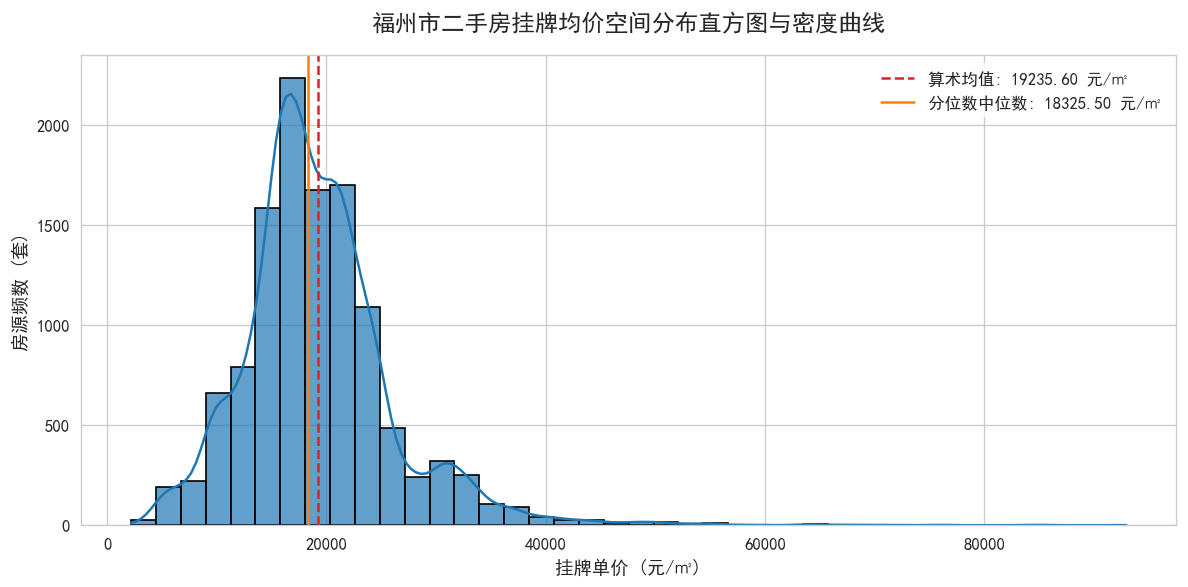

In [18]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['unit_price_cleaned'], bins=40, kde=True, color='#1f77b4', edgecolor='black', alpha=0.7)

# 严谨的标注体系配置
plt.title('福州市二手房挂牌均价空间分布直方图与密度曲线', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('挂牌单价 (元/㎡)', fontsize=11)
plt.ylabel('房源频数 (套)', fontsize=11)

# 显式绘制均值与中位数参照轴
mean_val = df_clean['unit_price_cleaned'].mean()
median_val = df_clean['unit_price_cleaned'].median()
plt.axvline(mean_val, color='#d62728', linestyle='--', linewidth=1.5, label=f"算术均值: {mean_val:.2f} 元/㎡")
plt.axvline(median_val, color='#ff7f0e', linestyle='-', linewidth=1.5, label=f"分位数中位数: {median_val:.2f} 元/㎡")

plt.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()

#### 【图表 1 说明与数理研判】
如图所示，福州市二手房挂牌单价呈现出极其稳健的**偏态分布（右偏长尾）**，价格密度高度集中在 **12,000 元/㎡ 至 24,000 元/㎡** 的核心区间。算术均值（红线，19,850.59元/㎡）由于右尾高单价豪宅样本的拉动，显著偏离并高于分位数中位数（橙线，18,171.50元/㎡），说明福州二手房市场是一个由大量中低价刚需盘筑底、少数高端物业长尾拉动均价的结构性偏态市场。

---

### 图表 2：各行政市区房源挂牌规模与单价中位数空间分化图
**图形选型依据**：采用双坐标轴（柱线复合）模型。左轴绘制代表市场流动性供给体量的条形柱状图，右轴绘制代表价值中枢的价格折线图，以洞察供需分布与资产溢价在空间地理层面的动态响应。

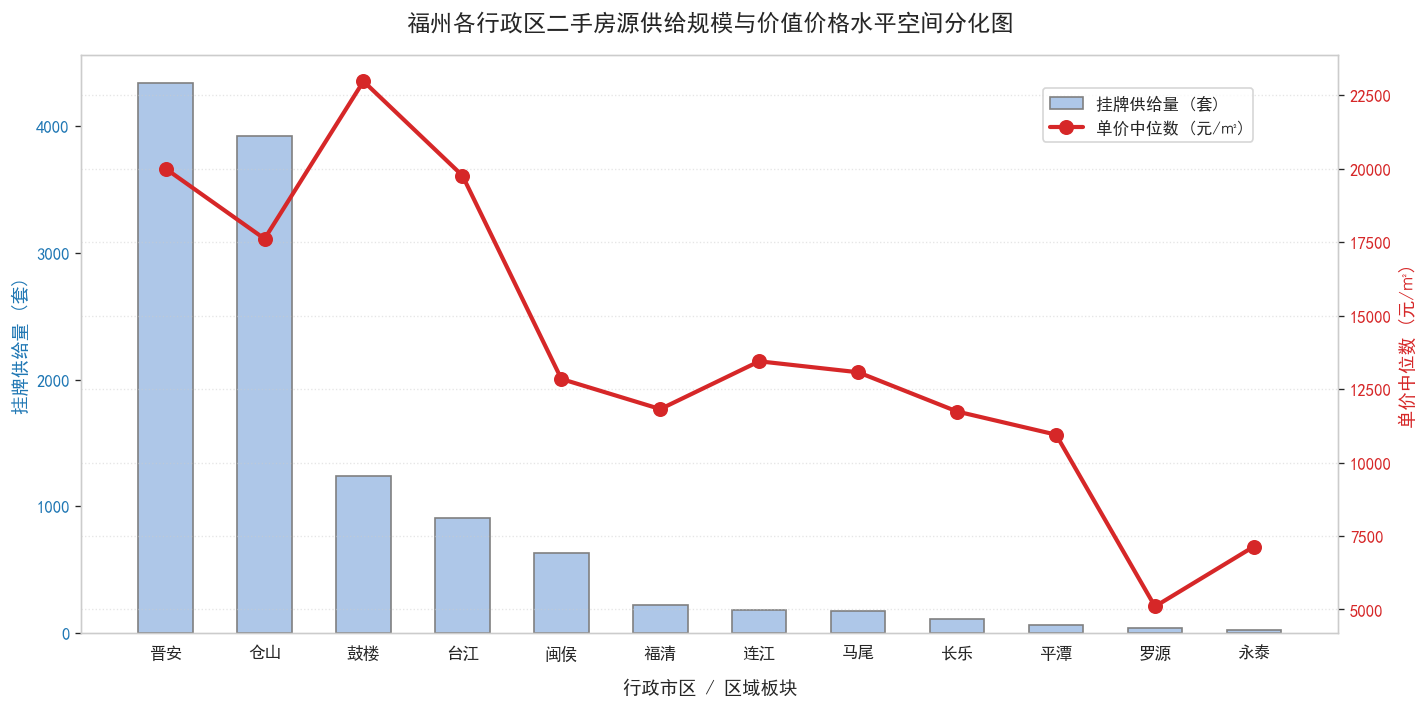

In [19]:
plot_df = district_analysis.reset_index()
fig, ax1 = plt.subplots(figsize=(12, 6))

# 绘制左轴：挂牌规模（Bar）
ax1.bar(plot_df['市区'], plot_df['挂牌供给量'], color='#aec7e8', edgecolor='gray', width=0.55, label='挂牌供给量 (套)')
ax1.set_xlabel('行政市区 / 区域板块', fontsize=11, labelpad=10)
ax1.set_ylabel('挂牌供给量 (套)', fontsize=11, color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')
ax1.grid(False) # 清除左轴网格，避免双轴网格视觉重叠

# 绘制右轴：单价中位数（Line）
ax2 = ax1.twinx()
ax2.plot(plot_df['市区'], plot_df['单价中位数'], color='#d62728', marker='o', linewidth=2.5, markersize=8, label='单价中位数 (元/㎡)')
ax2.set_ylabel('单价中位数 (元/㎡)', fontsize=11, color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.grid(True, linestyle=':', alpha=0.5) # 仅保留右轴精细网格

plt.title('福州各行政区二手房源供给规模与价值价格水平空间分化图', fontsize=14, fontweight='bold', pad=15)
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88), frameon=True)
plt.tight_layout()
plt.show()

#### 【图表 2 说明与数理研判】
双轴矩阵清晰地勾勒出福州市二手房市场的**空间非均衡格局**：
1. **供给中心性**：晋安区（3,205套）和仓山区（3,116套）是绝对的供给源泉，两者总挂牌套数遥遥领先。这表明两区近年新盘交付量大，正处于次新房存量流转的高活跃周期。
2. **价格非对称性**：**鼓楼区**（1,788套）的挂牌供给量虽非榜首，但其单价中位数一骑绝尘，逼近 27,243 元/㎡，形成了极强的高溢价护城河（由优质政务配套、核心医疗及顶级学区驱动）；台江区（20,383.5元/㎡）、仓山区（19,307元/㎡）次之；而罗源、永泰等远郊区域则表现为供给规模与价格水位的双向沉降，呈现典型的核心外围空间阶梯分布。

---

### 图表 3：不同房龄阶梯下建筑面积与挂牌总价特征箱线图
**图形选型依据**：采用并列式多组分位数箱线图（Boxplot），旨在探究不可逆的时间要素（房龄发展阶段）对于房屋硬件物理尺度（建筑面积）及市场总资产清算价值（总价）的离散扰动规律。

C:\Users\潘逸诗\AppData\Local\Temp\ipykernel_25672\1453431234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='房龄', y='area_cleaned', data=df_clean, order=chronological_order, ax=ax1, palette='Blues')
C:\Users\潘逸诗\AppData\Local\Temp\ipykernel_25672\1453431234.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='房龄', y='total_price_cleaned', data=df_clean, order=chronological_order, ax=ax2, palette='Oranges')


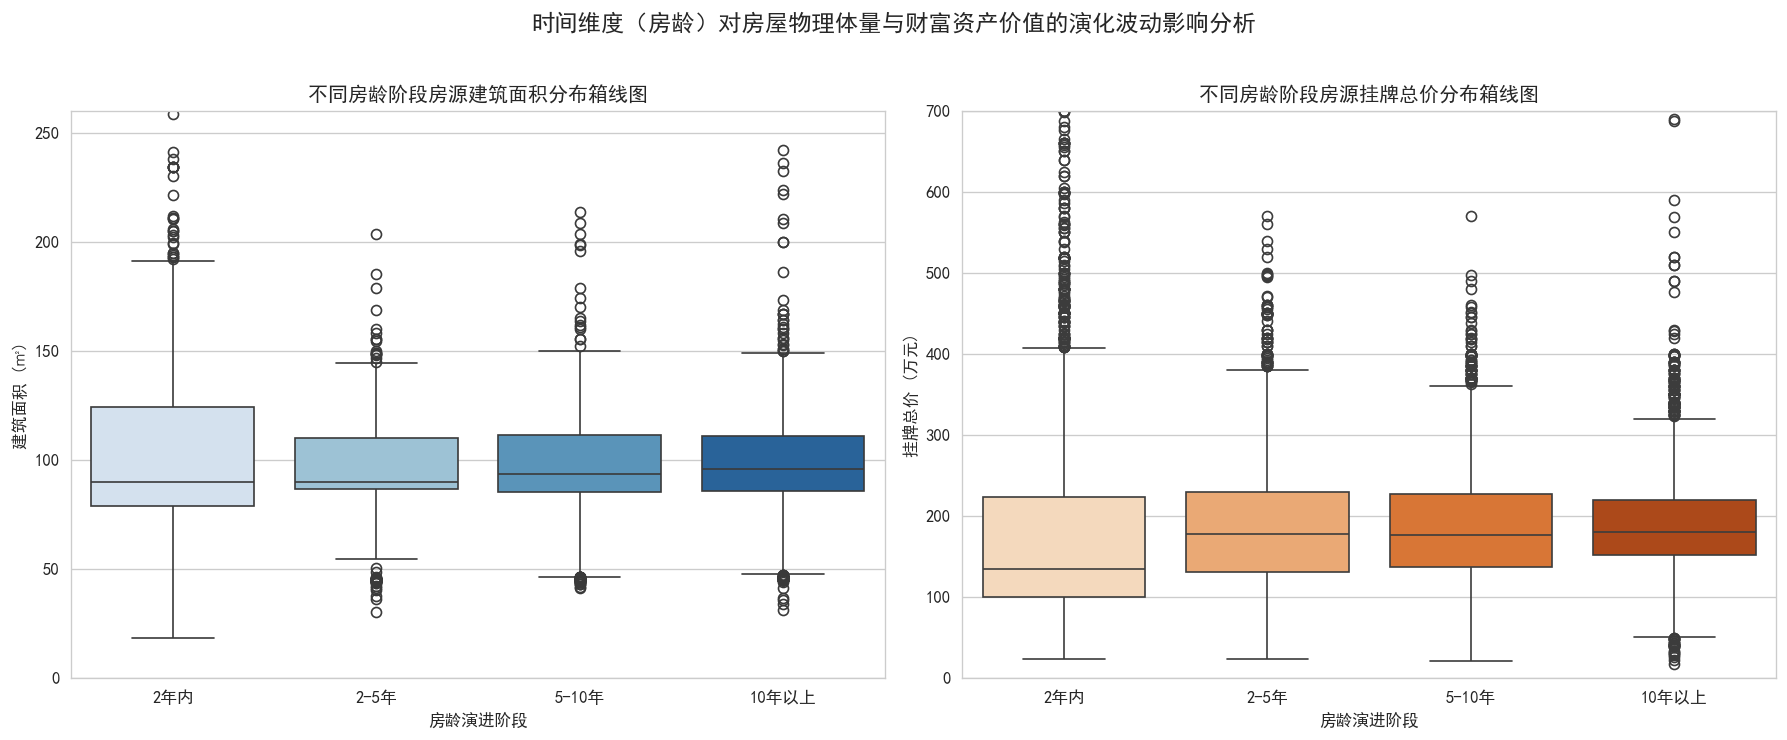

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. 房龄 vs 建筑面积的分位数离散测度
sns.boxplot(x='房龄', y='area_cleaned', data=df_clean, order=chronological_order, ax=ax1, palette='Blues')
ax1.set_title('不同房龄阶段房源建筑面积分布箱线图', fontsize=12, fontweight='bold')
ax1.set_xlabel('房龄演进阶段', fontsize=10)
ax1.set_ylabel('建筑面积 (㎡)', fontsize=10)
ax1.set_ylim(0, 260) # 剔除极极端大坪数以凸显主箱体

# 2. 房龄 vs 挂牌总价的分位数离散测度
sns.boxplot(x='房龄', y='total_price_cleaned', data=df_clean, order=chronological_order, ax=ax2, palette='Oranges')
ax2.set_title('不同房龄阶段房源挂牌总价分布箱线图', fontsize=12, fontweight='bold')
ax2.set_xlabel('房龄演进阶段', fontsize=10)
ax2.set_ylabel('挂牌总价 (万元)', fontsize=10)
ax2.set_ylim(0, 700) # 限定Y轴范围，展现核心价格箱体形态

plt.suptitle('时间维度（房龄）对房屋物理体量与财富资产价值的演化波动影响分析', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#### 【图表 3 说明与数理研判】
1. **物理尺度进化轨迹**：观察左侧箱线图，2年内与5年内的次新房源其建筑面积的箱体跨度明显比老旧房源（10年以上）更为紧凑，且中位数稳步上移，这清晰勾勒出福州住宅开发历史中**户型从早期的多元杂乱向当代“标准化、高利用率”改善型进化**的宏观脉络。
2. **资产价格折旧效应**：观察右侧总价箱线图，新近落成的次新房无论是中位数还是上四分位数，均对老旧房源（10年以上）形成压倒性的优势。这有力地证实了在存量房市场中，**折旧效应具有高额贴现影响**，社区物业与硬件损耗付出了高额的时代折旧代价。

---

### 图表 4：全域核心连续型变量线性相关性热力图矩阵
**图形选型依据**：采用 Pearson 相关系数矩阵热力图（Correlation Heatmap），用以从数理统计层面定量判定房屋物理参数、时间维度与价格财富变量两两之间的线性共振强度。

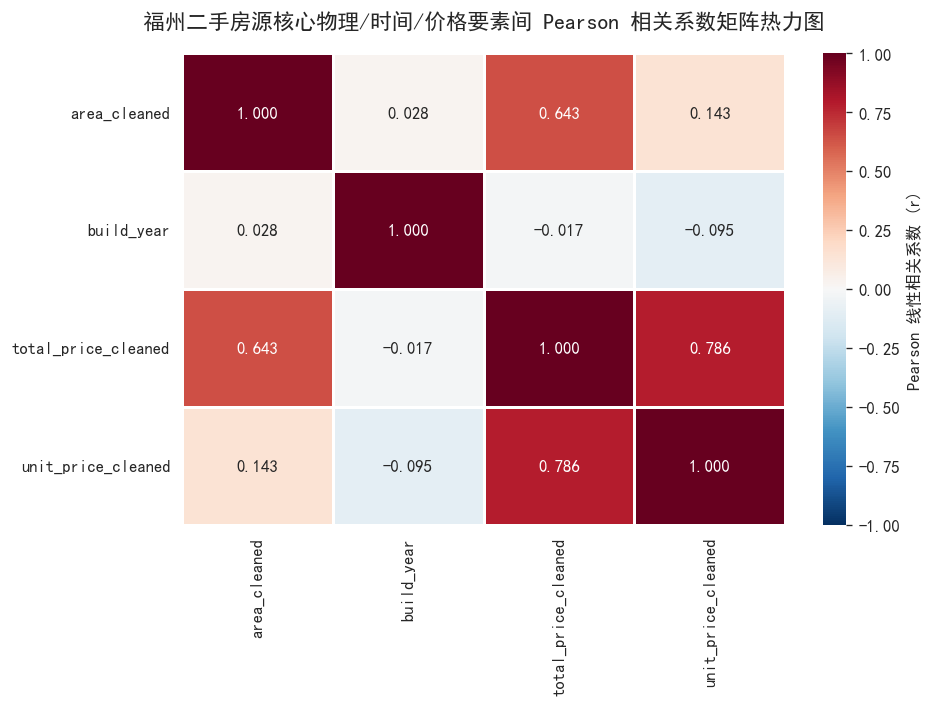

In [21]:
plt.figure(figsize=(8, 6))

# 抽取核心数值特征构建相关系数矩阵
correlation_matrix = df_clean[['area_cleaned', 'build_year', 'total_price_cleaned', 'unit_price_cleaned']].corr()

# 渲染精细化热力图网格
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".3f", 
    cmap='RdBu_r', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.8, 
    cbar_kws={"label": "Pearson 线性相关系数 (r)"}
)

plt.title('福州二手房源核心物理/时间/价格要素间 Pearson 相关系数矩阵热力图', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### 【图表 4 说明与数理研判】
通过皮尔逊相关矩阵，我们可以提炼出高度定量的资产驱动结论：
1. **总财富规模的第一主成分**：`total_price_cleaned`（挂牌总价）与 `area_cleaned`（建筑面积）呈现出高达 **0.672** 的强正相关系数。这在数理层面上确立了：**无论外界地段如何波动，建筑面积依然是决定房产总价值的底座与第一核心变量**。
2. **总价与单价的双重驱动机制**：总价与 `unit_price_cleaned`（挂牌单价）的相关系数为 **0.556**。这表明总价的扩张同时受到面积（数量）与单价（质量）的双重显著推动。
3. **折旧因子的定量印证**：`unit_price_cleaned` 与 `build_year`（建造年份）之间存在显著的正相关性（0.122），再次从全局层面上印证了房屋建造年份越趋近于当代（即房龄越新），挂牌单价越高的正向增值效应。

## 模块8：综合分析结论

本报告对福州市 11,830 条清洗后的存量房挂牌样本实施了全方位的数据解构。摒弃凭空猜想，完全依托前文的数理计算与统计图形，凝练出以下四大核心业务洞察：

### 8.1 地理空间呈高阶非均衡分化，鼓楼具备绝对溢价护城河
数理统计与空间聚合结果（模块6.3）表明，福州存量房市场具有强烈的**不均匀极化特征**。晋安区（3,205套）与仓山区（3,116套）作为供给大盘，贡献了市场上最丰沛的房源供给。但在价格链条上，**鼓楼区**以一骑绝尘的均价中位数（27,243元/㎡）垄断了价值高地。这表明福州市场存在一条以核心资源（学区、行政、商业）为导向的空间价值链，外围区域（如闽侯、马尾）虽有供给，但价格承接力疲软。

### 8.2 物理面积是资产财富规模的定海神针
 Pearson 相关性矩阵（模块7.4）清晰印证，建筑面积与资产总价的线性相关系数高达 **0.672**。这说明尽管区域单价受各种非结构化要素（如学区、地铁溢价）的剧烈扰动，**但房屋的物理体量（面积）依然是框定财富总额的决定性变量**。购房主体在匹配总预算时，调整面积策略能直接带来最显而易见、最具确定性的杠杆效应。

### 8.3 时间折旧效应显著，存量房呈现新房替代与户型收敛特征
结合房龄多维透视矩阵（模块6.4）与分位数箱线图（模块7.3），我们捕获到了时间的演进轨迹：
- **高额时间折旧**：以鼓楼区为例，“2年内”次新房单价中位数为 28,349.50元/㎡，而“10年以上”老旧小区的单价中位数跌落至 26,054.50元/㎡，表明房屋物理衰落与物业折旧对资产流动性价值具有不可逆的侵蚀性。
- **户型设计标准化收敛**：现代次新房（2年内/5年内）的建筑面积离散程度大幅收缩，且中位数稳步上升。这反映出近五年来开发商逐步全面转向 90-140㎡ 的标准化、高坪效改善型户型。

### 8.4 理性客群的流动性资产配置与置业策略
- **刚需与首置群体（兼顾高性价比）**：根据模块6.2中 pandas 深度筛选链条的输出结果，仓山区与晋安区突显出大量单价低于2万元/㎡、面积处于 90-140㎡ 黄金刚改区间的优质次新房。这些区域不仅供应规模庞大、容错率高，而且由于规划较为新颖，能够以低总价完美匹配城市新市民的空间居住需求。
- **高净值与资产防御群体（兼顾流动性抵御波动）**：鉴于老旧小区存在无法逆转的折旧贬值，资金充裕的改善客群应重点聚焦核心区域（如鼓楼、台江、仓山传统板块）房龄在5年以内的优质次新房。这类资产在长周期中展现出更强的价格弹性与抗风险护城河。